# Run Models

In [1]:
# Import Libraries
%run /Users/u4eeevmq/Documents/Python/HyporheicFloPy/VQuintana/notebooks/common_imports.py

# Retrieve stored variables
%store -r md6_exe_path
%store -r md7_exe_path
%store -r sim_name
%store -r workspace
%store -r figs_path
%store -r gwf_name
%store -r mp7_name
%store -r gwf_ws
%store -r mp7_ws
%store -r headfile
%store -r head_filerecord
%store -r budgetfile
%store -r budget_filerecord
%store -r write
%store -r run
%store -r plot
%store -r plot_show
%store -r plot_save

# Retrieve model parameters
%store -r length_units
%store -r time_units
%store -r nper
%store -r cell_size_x
%store -r cell_size_y
%store -r gw_mod_depth
%store -r z
%store -r kh
%store -r kv
%store -r gw_offset
%store -r porosity
%store -r rch_iface
%store -r rch_iflowface
%store -r recharge_rate
%store -r nstp
%store -r perlen
%store -r tsmult

# Retrieve spatial data
%store -r hec_ras_crs
%store -r terrain_elevation
%store -r raster_transform
%store -r transform
%store -r raster_crs
%store -r terrain_output_raster
%store -r water_surface_output_raster
%store -r cropped_output_raster
%store -r ground_water_domain
%store -r left_boundary
%store -r right_boundary

# retrieve model domain data
%store -r terrain_elevation
%store -r raster_transform
%store -r raster_crs
%store -r raster_bounds_box
%store -r bed_elevation
%store -r raster_width
%store -r raster_height
%store -r ncol
%store -r nrow
%store -r top
%store -r nlay
%store -r grid_x
%store -r grid_y
%store -r grid_points
%store -r intersecting_points
%store -r xorigin
%store -r yorigin
%store -r xmin
%store -r ymin
%store -r xmax
%store -r ymax
%store -r tops
%store -r botm

# retrieve model boundary data
%store -r left_start
%store -r left_end
%store -r right_start
%store -r right_end
%store -r upstream_start_x
%store -r upstream_start_y
%store -r upstream_end_x
%store -r upstream_end_y
%store -r downstream_start_x
%store -r downstream_start_y
%store -r downstream_end_x
%store -r downstream_end_y
%store -r upstream_line
%store -r downstream_line
%store -r upstream_boundary
%store -r downstream_boundary
%store -r grid_cells
%store -r grid_gdf
%store -r idomain

# retrieve model boundary conditions
%store -r boundary_cells
%store -r left_boundary_cells
%store -r right_boundary_cells
%store -r upstream_boundary_cells
%store -r downstream_boundary_cells
%store -r all_boundary_cells
%store -r unique_boundary_cells
%store -r left_boundary_cells_first_layer
%store -r right_boundary_cells_first_layer
%store -r upstream_boundary_cells_first_layer
%store -r downstream_boundary_cells_first_layer
%store -r max_elevation_upstream
%store -r max_elevation_downstream
%store -r gw_elevation_left_first
%store -r gw_elevation_left_last
%store -r gw_elevation_right_first
%store -r gw_elevation_right_last
%store -r gw_elevation_upstream_first
%store -r gw_elevation_upstream_last
%store -r gw_elevation_downstream_first
%store -r gw_elevation_downstream_last
%store -r gw_elevation_left
%store -r gw_elevation_right
%store -r gw_elevation_upstream
%store -r gw_elevation_downstream
%store -r grid_points_coords
%store -r elevation_values
%store -r grid_points_df
%store -r output_csv
%store -r cropped_df
%store -r river_cells
%store -r river_x
%store -r river_y
%store -r river_elevation
%store -r chd_data
%store -r unique_chd_cells
%store -r duplicate_chd_cells
%store -r chd_data_converted

# retrieve well data
%store -r wel_data

# retrieve nodes
# %store -r nodes


In [2]:
# Initialize cfg with required attributes
cfg = SimpleNamespace(
    # Simulation and workspace settings
    sim_name=sim_name,
    gwf_ws=gwf_ws,
    gwf_name =gwf_name,
    mp7_name=mp7_name,
    mp7_ws=mp7_ws,
    md6_exe_path=md6_exe_path,
    md7_exe_path=md7_exe_path,
    raster_crs=raster_crs,  # Coordinate reference system of the raster
    ground_water_domain=ground_water_domain,  # GeoDataFrame for groundwater domain
    left_boundary=left_boundary,  # GeoDataFrame for left boundary
    right_boundary=right_boundary,  # GeoDataFrame for right boundary
    cropped_water_surface_raster=cropped_output_raster,  # Cropped water surface raster
    gw_offset=gw_offset,  # Offset below water surface elevation
    nper =nper,  # Number of stress periods
    perlen =perlen,  # Length of each stress period
    tsmult =tsmult,  # Time step multiplier
    nstp =nstp,  # Number of time steps per stress period
    cell_size_x=cell_size_x,  # Cell size in x-direction
    cell_size_y=cell_size_y,  # Cell size in y-direction
    xmin=xmin,  # Minimum x-coordinate of the grid
    ymin=ymin,  # Minimum y-coordinate of the grid
    xmax=xmax,  # Maximum x-coordinate of the grid
    ymax=ymax,  # Maximum y-coordinate of the grid
    nlay=nlay,  # Number of layers
    nrow=nrow,  # Number of rows
    ncol=ncol,  # Number of columns
    tops=tops,  # List of top elevations for each layer
    botm=botm,  # List of bottom elevations for each layer
    grid_x=grid_x,  # Grid x-coordinates
    grid_y=grid_y,  # Grid y-coordinates
    grid_points=grid_points,  # GeoDataFrame of grid points
    length_units = length_units,
    time_units = time_units,
    budgetfile=budgetfile,  # Budget file name
    headfile=headfile,  # Head file name
    bed_elevation=bed_elevation,  # Bed elevation
    kv =kv,  # Vertical hydraulic conductivity
    kh =kh,  # Horizontal hydraulic conductivity
    porosity=porosity,  # Porosity
    gw_mod_depth=gw_mod_depth,  # Depth of the groundwater model
)

# Debugging: Print cfg to verify attributes
print(cfg)

namespace(sim_name='Hyporheic_Project', gwf_ws=WindowsPath('HP_workspace/gwf_workspace'), gwf_name='gwf_model', mp7_name='mp7_model', mp7_ws=WindowsPath('HP_workspace/mp7_workspace'), md6_exe_path='C:\\Users\\u4eeevmq\\Documents\\Python\\Flo_Py\\flopy\\modflowExe\\mf6.exe', md7_exe_path='C:\\Users\\u4eeevmq\\Documents\\Python\\Flo_Py\\flopy\\modflowExe\\mp7.exe', raster_crs=CRS.from_wkt('PROJCS["NAD83 / Texas Central (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",29.6666666666667],PARAMETER["central_meridian",-100.333333333333],PARAMETER["standard_parallel_1",30.1166666666667],PARAMETER["standard_parallel_2",31.8833333333333],PARAMETER["false_easting",2296583.33333333],PARAMETER["false_northing",9842500]

## MODFLOW 6 Groundwater Model

In [3]:
#----------------------Model Setup Functions ------------------------#
def build_gwf_model(
    cfg: Any,                              # config/settings instance
    chd_data: Sequence[Sequence[float]],   # CHD rows/records
    idomain: np.ndarray,                   # (nlay, nrow, ncol) activity mask
) -> Tuple[flopy.mf6.MFSimulation, flopy.mf6.ModflowGwf]:
    """
    Construct a stand-alone MODFLOW 6 GWF model using information held
    in `cfg` plus the caller-supplied `chd_data` and `idomain` array.

    Returns
    -------
    (sim, gwf) tuple – ready for sim.write_simulation() and sim.run_simulation().
    """
    # --- Sanity checks -------------------------------------------------
    if cfg.nlay is None or cfg.nrow is None or cfg.ncol is None:
        raise ValueError("cfg.nlay / nrow / ncol must be populated first.")
    if idomain.shape != (cfg.nlay, cfg.nrow, cfg.ncol):
        raise ValueError("`idomain` dimensions don’t match cfg grid.")

    # --- 1. Simulation container ---------------------------------------
    sim = flopy.mf6.MFSimulation(
        sim_name = cfg.sim_name,
        exe_name = str(cfg.md6_exe_path),
        sim_ws   = str(cfg.gwf_ws),
    )

    flopy.mf6.ModflowTdis(
        sim,
        time_units = cfg.time_units.upper(),
        nper       = cfg.nper,
        perioddata = [(cfg.perlen, cfg.nstp, cfg.tsmult)],
    )

    # --- 2. Groundwater-flow model -------------------------------------
    gwf = flopy.mf6.ModflowGwf(
        sim,
        modelname  = cfg.gwf_name,
        save_flows = True,
    )

    flopy.mf6.ModflowGwfdis(
        gwf,
        nlay    = cfg.nlay,
        nrow    = cfg.nrow,
        ncol    = cfg.ncol,
        delr    = cfg.cell_size_x,
        delc    = cfg.cell_size_y,
        top     = cfg.tops[0],
        botm    = cfg.botm,
        idomain = idomain,
        xorigin = cfg.xmin,
        yorigin = cfg.ymin,
    )

    # Set or update the model grid crs and coordinate info
    gwf.modelgrid.crs = cfg.raster_crs
    gwf.modelgrid.set_coord_info(cfg.xmin, cfg.ymin, crs=cfg.raster_crs)

    # --- 3. Packages ---------------------------------------------------
    # 3-a. initial heads
    strt = np.full((cfg.nlay, cfg.nrow, cfg.ncol), cfg.bed_elevation, dtype=float)
    flopy.mf6.ModflowGwfic(gwf, strt=strt)

    # 3-b. hydraulic properties
    flopy.mf6.ModflowGwfnpf(
        gwf,
        icelltype = 2,
        k         = cfg.kh,
        k33       = cfg.kv,
        save_flows        = True,
        save_saturation   = True,
        save_specific_discharge = True,
    )

    # 3-c. constant-head boundaries
    if chd_data:
        flopy.mf6.ModflowGwfchd(
            gwf,
            maxbound           = len(chd_data),
            stress_period_data = {0: chd_data},
            save_flows         = True,
        )

    # 3-d. output control
    flopy.mf6.ModflowGwfoc(
        gwf,
        saverecord        = [("HEAD", "ALL"), ("BUDGET", "ALL")],
        head_filerecord   = [cfg.headfile],
        budget_filerecord = [cfg.budgetfile],
        printrecord       = [("HEAD", "LAST")],
    )

    # --- 4. IMS solver -------------------------------------------------
    flopy.mf6.ModflowIms(
        sim,
        print_option      = "SUMMARY",
        outer_dvclose     = 1e-4,
        outer_maximum     = 200,
        inner_maximum     = 500,
        inner_dvclose     = 1e-4,
        rcloserecord      = 1e-4,
        linear_acceleration = "BICGSTAB",
        relaxation_factor = 0.97,
    )

    # --- 5. Externalize big arrays for disk IO & QA --------------------
    external_dir = Path(gwf.model_ws) / "arrays"
    external_dir.mkdir(exist_ok=True)

    dis = gwf.get_package("DIS")
    ic  = gwf.get_package("IC")

    def _layered_records(array: np.ndarray, basename: str) -> list[dict]:
        return [{
            "filename": str(PurePath("arrays") / f"{basename}_L{lay+1}.bin"),
            "binary": True,
            "data": np.asarray(array[lay]),
            "iprn": 0,
            "factor": 1.0,
        } for lay in range(array.shape[0])]

    # Externalize DIS arrays
    if dis is not None:
        dis.top.set_record({
            "filename": str(PurePath("arrays") / "top.bin"),
            "binary": True,
            "data": np.asarray(dis.top.array),
            "iprn": 0,
            "factor": 1.0,
        })
        dis.botm.set_record(_layered_records(dis.botm.array, "botm"))
        if hasattr(dis, "idomain") and dis.idomain.array is not None:
            dis.idomain.set_record(_layered_records(dis.idomain.array, "idomain"))

    # Externalize IC array
    if ic is not None:
        ic.strt.set_record(_layered_records(ic.strt.array, "strt"))

    return sim, gwf

## MODPATH 7 Particle Tracking

In [4]:
def build_particle_models(
    sim_name: str,
    gwf: flopy.mf6.ModflowGwf,
    river_cells: list[tuple[int, int, int]],
    *,
    mp7_ws: Path | str | None = None,
    exe_path: str | Path | None = None,
) -> tuple[Modpath7, Modpath7]:
    """
    Create **forward** *and* **backward** MODPATH 7 models that start particles
    in every cell listed in *river_cells*.

    Parameters
    ----------
    sim_name      : str
        Base name – “_mp_forward / _mp_backward” are appended automatically.
    gwf           : flopy.mf6.ModflowGwf
        The built groundwater-flow model whose grid MODPATH inherits.
    river_cells   : list[(k, i, j)]
        Sequence of (layer,row,col) indices where particles should be released.
    mp7_ws, exe_path
        Optional overrides.  If omitted workspace & exe are taken from *gwf*
        (``gwf.simulation.sim_path`` and ``os.getenv("MP7")``).

    Returns
    -------
    (mp_forward, mp_backward) : tuple[flopy.modpath.Modpath7, Modpath7]
    """
    # ── defaults from the GWF simulation ──────────────────────────────
    if mp7_ws is None:
        mp7_ws = Path(gwf.simulation.sim_path).parent / "mp7_workspace"
    mp7_ws = Path(mp7_ws).absolute()
    mp7_ws.mkdir(exist_ok=True)

    if exe_path is None:
        exe_path = "mp7"   # rely on PATH

    def _make(direction: str) -> flopy.modpath.Modpath7:
        mp = Modpath7.create_mp7(
            modelname=f"{sim_name}_mp_{direction}",
            trackdir=direction,
            flowmodel=gwf,
            model_ws=mp7_ws,
            exe_name=str(exe_path),
            rowcelldivisions=1,
            columncelldivisions=1,
            layercelldivisions=1,
        )

        # Particle locations: ensure only (k, i, j) shape
        partlocs = [(k, i, j) for (k, i, j, *_) in river_cells]

        # Create ParticleData and ParticleGroup
        particle_data = ParticleData(partlocs, structured=True, drape=0)
        pg = ParticleGroup(particledata=particle_data)

        # Assign to model's MPSIM package
        mpsim = mp.get_package("MPSIM")
        mpsim.particlegroups.clear()
        mpsim.particlegroups.append(pg)

        return mp

    mp_forward  = _make("forward")
    mp_backward = _make("backward")
    return mp_forward, mp_backward

## Simulation Settings

In [5]:
def write_models(*sims, silent=False):
    for sim in sims:
        if isinstance(sim, flopy.mf6.MFSimulation):
            sim.write_simulation(silent=silent)
        else:
            sim.write_input()

@timed
def run_models(*sims, silent=False):
    for sim in sims:
        if isinstance(sim, flopy.mf6.MFSimulation):
            print(f"Running simulation: {sim.name}")
            success, buff = sim.run_simulation(silent=silent, report=True)
        else:
            print(f"Running model: {sim.name}")
            success, buff = sim.run_model(silent=silent, report=True)
        
        if not success:
            print(f"Simulation {sim.name} failed.")
            print(buff)
            break
        else:
            print(f"Simulation {sim.name} succeeded.")

In [6]:
## Plot Groundwater Model Results
def load_head():
    # Assuming you have a head file to load
    head_file = gwf_ws / headfile
    head_obj = flopy.utils.HeadFile(head_file)
    head = head_obj.get_data()
    return head

def plot_gwf_all(gwfsim):
    # get gwf model
    gwf = gwfsim.get_model(gwf_name)
    head = load_head()

    # Load the discretization file to access model grid information
    dis = gwf.get_package("DIS")
    nlay, nrow, ncol = dis.nlay.data, dis.nrow.data, dis.ncol.data

    # Load the idomain array to identify active cells
    idomain = dis.idomain.array # No results will be visible otherwise

    # Choose the layer you want to plot, e.g., the first layer (layer 0)
    layer_to_plot = 1  # You can change this to any other layer (0-based index)

    # Extract the groundwater head for the specified layer (nrow, ncol)
    head_layer = head[layer_to_plot, :, :]

    # Mask the inactive cells in the head_layer array
    head_layer_masked = np.ma.masked_where(idomain[layer_to_plot, :, :] == 0, head_layer)

    # Plot the groundwater head for the chosen layer
    plt.figure(figsize=(10, 6))
    plt.imshow(head_layer_masked, cmap='viridis', origin='lower', extent=[0, ncol, 0, nrow])
    plt.colorbar(label='Groundwater Head (m)')
    plt.title(f'Groundwater Head at Layer {layer_to_plot + 1}')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.show()

    # Load the surface elevation data
    surface_elevation = dis.top.array

    # Choose the layers you want to plot, e.g., the first layer (layer 0) and the last layer
    layer_to_plot_first = 0  # First layer (0-based index)
    layer_to_plot_last = nlay - 1  # Last layer (0-based index)

    # Extract the groundwater head for the specified layers (nrow, ncol)
    head_layer_first = head[layer_to_plot_first, :, :]
    head_layer_last = head[layer_to_plot_last, :, :]

    # Mask the inactive cells in the head_layer arrays
    head_layer_first_masked = np.ma.masked_where(idomain[layer_to_plot_first, :, :] == 0, head_layer_first)
    head_layer_last_masked = np.ma.masked_where(idomain[layer_to_plot_last, :, :] == 0, head_layer_last)

    # Plot the surface elevation for active cells and overlay groundwater head contours
    fig, axs = plt.subplots(1, 2, figsize=(20, 10))

    # Plot for the first layer
    top_active_first = np.ma.masked_where(idomain[layer_to_plot_first, :, :] == 0, surface_elevation)
    im1 = axs[0].imshow(top_active_first, cmap="terrain", interpolation="nearest", origin="lower",
                        extent=[0, ncol, 0, nrow], alpha=0.7)
    plt.colorbar(im1, ax=axs[0], label='Surface Elevation (m)')

    # Check if the minimum and maximum values are different before creating contour levels
    if head_layer_first_masked.min() != head_layer_first_masked.max():
        contour_first = axs[0].contour(head_layer_first_masked, levels=np.linspace(head_layer_first_masked.min(), head_layer_first_masked.max(), 10), colors='blue', extent=[0, ncol, 0, nrow])
        axs[0].clabel(contour_first, inline=True, fontsize=8, fmt='%1.1f')
    axs[0].set_title(f'Surface Elevation and Groundwater Head Contours at Layer {layer_to_plot_first + 1}')
    axs[0].set_xlabel('Column')
    axs[0].set_ylabel('Row')

    # Plot for the last layer
    top_active_last = np.ma.masked_where(idomain[layer_to_plot_last, :, :] == 0, surface_elevation)
    im2 = axs[1].imshow(top_active_last, cmap="terrain", interpolation="nearest", origin="lower",
                        extent=[0, ncol, 0, nrow], alpha=0.7)
    plt.colorbar(im2, ax=axs[1], label='Surface Elevation (m)')

    # Check if the minimum and maximum values are different before creating contour levels
    if head_layer_last_masked.min() != head_layer_last_masked.max():
        contour_last = axs[1].contour(head_layer_last_masked, levels=np.linspace(head_layer_last_masked.min(), head_layer_last_masked.max(), 10), colors='blue', extent=[0, ncol, 0, nrow])
        axs[1].clabel(contour_last, inline=True, fontsize=8, fmt='%1.1f')
    axs[1].set_title(f'Surface Elevation and Groundwater Head Contours at Layer {layer_to_plot_last + 1}')
    axs[1].set_xlabel('Column')
    axs[1].set_ylabel('Row')

    plt.tight_layout()
    plt.show()

    #---------------------- Zoom In to idomain ------------------------#
    # Choose the layers you want to plot
    layers_to_plot = [1, 19, 39]  # 1st, 20th, and 40th layers (0-based index)

    # Extract the groundwater head for the specified layers (nrow, ncol)
    head_layers = [head[layer, :, :] for layer in layers_to_plot]

    # Mask the inactive cells in the head_layer arrays
    head_layers_masked = [np.ma.masked_where(idomain[layer, :, :] == 0, head_layers[i]) for i, layer in enumerate(layers_to_plot)]

    # Determine the extent of the active cells
    active_cells = np.any(idomain, axis=0)
    active_rows, active_cols = np.where(active_cells)
    row_min, row_max = active_rows.min(), active_rows.max()
    col_min, col_max = active_cols.min(), active_cols.max()

    # Define the extent for the plots
    extent = [col_min, col_max + 1, row_min, row_max + 1]

    # Plot the surface elevation for active cells and overlay groundwater head contours
    fig, axs = plt.subplots(3, 1, figsize=(10, 30))

    for i, layer in enumerate(layers_to_plot):
        # Plot for each layer
        top_active = np.ma.masked_where(idomain[layer, :, :] == 0, surface_elevation)
        im = axs[i].imshow(top_active[row_min:row_max+1, col_min:col_max+1], cmap="terrain", interpolation="nearest", origin="lower",
                           extent=extent, alpha=0.7)
        plt.colorbar(im, ax=axs[i], label='Surface Elevation (m)')
        contour = axs[i].contour(head_layers_masked[i][row_min:row_max+1, col_min:col_max+1], levels=np.linspace(head_layers_masked[i].min(), head_layers_masked[i].max(), 10), colors='blue', extent=extent)
        axs[i].clabel(contour, inline=True, fontsize=8, fmt='%1.1f')
        axs[i].set_title(f'Surface Elevation and Groundwater Head Contours at Layer {layer + 1}')
        axs[i].set_xlabel('Column')
        axs[i].set_ylabel('Row')

    plt.tight_layout()
    plt.show()

    #---------------------- 3D Plot of the Model ------------------------#
    top = dis.top.array
    botm = dis.botm.array
    idomain = dis.idomain.array  # Assuming idomain is part of the dis object

    # Combine top and botm to get the elevation data for all layers
    elevation_data = np.concatenate(([top], botm), axis=0)

    # Get the number of rows and columns
    nrows, ncols = top.shape

    # Layer to plot for terrain
    terrain_layer = 0

    # Create a meshgrid for x and y coordinates
    x = np.linspace(0, ncols - 1, ncols)
    y = np.linspace(0, nrows - 1, nrows)
    x, y = np.meshgrid(x, y)

    # Mask the elevation data using the idomain array
    #z = np.ma.masked_where(idomain[terrain_layer, :, :] == 0, elevation_data[terrain_layer, :, :])

    # Set up plot
    fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))

    # Light source for hillshading
    ls = LightSource(270, 45)

    # Plot the masked elevation data
    z = elevation_data[terrain_layer, :, :]
    rgb = ls.shade(z, cmap=cm.gist_earth, vert_exag=0.1, blend_mode='soft')
    surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=rgb,
                        linewidth=0, antialiased=False, shade=False)

    # Set plot labels and title
    ax.set_title('3D Terrain Elevation')
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_zlabel('Elevation (ft)')

    plt.show()

## Code from:
# https://github.com/matplotlib/matplotlib/tree/cfe5bf75eaf378b9523830908036f2123acfe4e7/examples/frontpage/3D.py

In [7]:
def plot_groundwater_model(
    gwfsim,
    gwf_name,
    cfg=None,               # Optional: pass config if you want to get paths/extents/etc
    headfile=None,
    overlay_layer=0,
    head_cmap='viridis',
):
    """
    Plot 3D domain, 2D head and surface elevation, and optionally overlay head on satellite imagery.
    All geometry and file paths are inferred from the model objects and config.
    """
    import flopy

    gwf = gwfsim.get_model(gwf_name)
    dis = gwf.get_package("DIS")
    nlay, nrow, ncol = dis.nlay.data, dis.nrow.data, dis.ncol.data
    idomain = dis.idomain.array
    top = dis.top.array
    botm = dis.botm.array

    # Get coordinates for grid edges
    x = np.arange(ncol)
    y = np.arange(nrow)
    X, Y = np.meshgrid(x, y)

    # Head file path inference
    if headfile is None:
        # Try to infer headfile from config or default MODFLOW6 naming
        headfile = f"{gwf_name}.hds"
    try:
        head_file = gwf.model_ws / headfile
    except Exception:
        # If model_ws is not a pathlib.Path, just join as string
        import os
        head_file = os.path.join(gwf.model_ws, headfile)

    head_obj = flopy.utils.HeadFile(head_file)
    head = head_obj.get_data()

    # Check if accessing the model grid is possible
    print(gwf)
    print(gwf.modelgrid)

    layer_interfaces = np.empty((nlay+1, nrow, ncol), dtype=top.dtype)
    layer_interfaces[0, :, :] = top
    layer_interfaces[1:, :, :] = botm

    # fig = plt.figure(figsize=(10, 7))
    # ax = fig.add_subplot(111, projection='3d')

    # x = np.arange(ncol)
    # y = np.arange(nrow)
    # X, Y = np.meshgrid(x, y)

    # for iface in range(nlay+1):
    #     ax.plot_wireframe(X, Y, layer_interfaces[iface], color='gray', linewidth=0.5, alpha=0.7 if iface > 0 else 1.0)

    # # for k in range(nlay):
    # #     for j in range(nrow):
    # #         for i in range(ncol):
    # #             x0, x1 = i, i+1
    # #             y0, y1 = j, j+1
    # #             z_top = layer_interfaces[k, j, i]
    # #             z_bot = layer_interfaces[k+1, j, i]
    # #             # 4 vertical lines at cell corners
    # #             for dx in [0, 1]:
    # #                 for dy in [0, 1]:
    # #                     ax.plot(
    # #                         [x0+dx, x0+dx], [y0+dy, y0+dy], [z_bot, z_top],
    # #                         color='gray', linewidth=0.5, alpha=0.7
    # #                )

    # ax.set_xlabel('X')
    # ax.set_ylabel('Y')
    # ax.set_zlabel('Elevation')
    # plt.show()

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Top and bottom
    ax.plot_surface(X, Y, top, color='cyan', alpha=0.7)
    ax.plot_surface(X, Y, botm[-1], color='orange', alpha=0.7)

    # Sides
    # Left (x=0)
    y_side = np.arange(nrow)
    z_top = top[:, 0]
    z_bot = botm[-1, :, 0]
    X2, Y2 = np.meshgrid([0], y_side)
    Z2 = np.array([z_bot, z_top]).T
    ax.plot_surface(X2, Y2, Z2, color='red', alpha=0.7)

    # Right (x=ncol-1)
    y_side = np.arange(nrow)
    z_top = top[:, -1]
    z_bot = botm[-1, :, -1]
    X2, Y2 = np.meshgrid([ncol-1], y_side)
    Z2 = np.array([z_bot, z_top]).T
    ax.plot_surface(X2, Y2, Z2, color='blue', alpha=0.7)

    # Front (y=0)
    x_side = np.arange(ncol)
    z_top = top[0, :]
    z_bot = botm[-1, 0, :]
    X2, Y2 = np.meshgrid(x_side, [0])
    Z2 = np.array([z_bot, z_top])
    ax.plot_surface(X2, Y2, Z2, color='green', alpha=0.7)

    # Back (y=nrow-1)
    x_side = np.arange(ncol)
    z_top = top[-1, :]
    z_bot = botm[-1, -1, :]
    X2, Y2 = np.meshgrid(x_side, [nrow-1])
    Z2 = np.array([z_bot, z_top])
    ax.plot_surface(X2, Y2, Z2, color='purple', alpha=0.7)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Elevation')
    plt.show()

    # --- 2D HEAD AND SURFACE ELEVATION PLOTS (top and bottom) ---
    layers_to_plot = [0, nlay - 1]
    surface_elevation = top
    fig, axs = plt.subplots(1, 2, figsize=(20, 8))
    for i, layer in enumerate(layers_to_plot):
        head_layer = head[layer, :, :]
        head_layer_masked = np.ma.masked_where(idomain[layer, :, :] == 0, head_layer)
        top_active = np.ma.masked_where(idomain[layer, :, :] == 0, surface_elevation)
        im1 = axs[i].imshow(top_active, cmap="terrain", origin="lower", extent=[0, ncol, 0, nrow], alpha=0.7)
        plt.colorbar(im1, ax=axs[i], label='Surface Elevation (m)')
        if head_layer_masked.min() != head_layer_masked.max():
            contour = axs[i].contour(
                head_layer_masked,
                levels=np.linspace(head_layer_masked.min(), head_layer_masked.max(), 10),
                colors='blue',
                extent=[0, ncol, 0, nrow],
            )
            axs[i].clabel(contour, inline=True, fontsize=8, fmt='%1.1f')
        axs[i].set_title(f'Surface Elevation & Head Contours at Layer {layer+1}')
        axs[i].set_xlabel('Column')
        axs[i].set_ylabel('Row')
    plt.tight_layout()
    plt.show()

    # --- GROUNDWATER HEAD OVER SATELLITE IMAGE (OPTIONAL) ---
    if cfg is not None and hasattr(cfg, 'sat_img') and hasattr(cfg, 'extent') and cfg.sat_img is not None:
        import matplotlib.image as mpimg
        img = mpimg.imread(cfg.sat_img)
        head_layer = head[overlay_layer, :, :]
        idomain_layer = idomain[overlay_layer, :, :]
        head_masked = np.ma.masked_where(idomain_layer == 0, head_layer)
        plt.figure(figsize=(14, 10))
        plt.imshow(img, extent=cfg.extent, origin='upper')
        plt.imshow(head_masked, cmap=head_cmap, alpha=0.5, origin='lower', extent=cfg.extent)
        plt.colorbar(label='Groundwater Head (m)')
        plt.title('Groundwater Head Overlaid on Satellite Imagery')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.tight_layout()
        plt.show()
        # Contours
        plt.figure(figsize=(14, 10))
        plt.imshow(img, extent=cfg.extent, origin='upper')
        CS = plt.contour(head_masked, levels=10, colors='cyan', linewidths=1, extent=cfg.extent)
        plt.clabel(CS, fmt='%1.1f', colors='cyan')
        plt.title('Groundwater Head Contours on Satellite Imagery')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.tight_layout()
        plt.show()

## Plot Particle Tracking Results

In [8]:
def process_and_export_modpath7_results(
    workspace,
    workspace_gwf,
    sim_name,
    gwf_model_name,
    hec_ras_crs,
    bed_elevation,
    ncol,
    nrow,
    nlay,
    river_cells,
    gwf,
    xorigin_value,
    yorigin_value,
    output_folder="Hyporheic_output",
    endpoints_file=None,
    pathline_file=None,
):
    os.makedirs(output_folder, exist_ok=True)
    # --- Load grid and head ---
    dis = gwf.get_package("DIS")
    delr = dis.delr.array
    delc = dis.delc.array
    idomain = dis.idomain.array
    delr_mean = np.mean(delr)
    delc_mean = np.mean(delc)
    extent = [xorigin_value, xorigin_value + delr.sum(), yorigin_value, yorigin_value + delc.sum()]

    # --- Files ---
    if pathline_file is None:
        pathline_file = os.path.join(workspace, sim_name + "_mp_forward.mppth")
    if endpoints_file is None:
        endpoints_file = os.path.join(workspace, sim_name + "_mp_forward.mpend")
    # --- Head ---
    hds = flopy.utils.HeadFile(os.path.join(workspace_gwf, f"{gwf_model_name}.hds"))
    head_array = hds.get_data()
    if head_array.ndim == 4:
        head_array = head_array[-1]
    # --- River cell coords for quick lookup ---
    river_cell_coords = [
        (
            sum(delr[:cell[2]]) + delr[cell[2]] / 2 + xorigin_value,
            sum(delc[:cell[1]]) + delc[cell[1]] / 2 + yorigin_value
        ) for cell in river_cells
    ]
    river_cell_coords_set = set(river_cell_coords)
    # --- Endpoints and filtered ids ---
    endpoint_reader = flopy.utils.EndpointFile(endpoints_file)
    endpoints = endpoint_reader.get_alldata()
    filtered_particles = [
        ep for ep in endpoints
        if (ep['z'] >= bed_elevation and (ep['x'], ep['y']) != (ep['x0'], ep['y0']) and abs(ep['z'] - ep['z0']) > 0)
    ]
    filtered_particle_ids = [int(ep['particleid']) for ep in filtered_particles]
    # --- Pathlines DataFrame ---
    pathline_reader = flopy.utils.PathlineFile(pathline_file)
    filtered_pathlines = []
    for pid in filtered_particle_ids:
        filtered_pathlines.extend(pathline_reader.get_data(partid=pid))
    column_names = [
        'particleid', 'particlegroup', 'sequencenumber', 'particleidloc', 'time',
        'x', 'y', 'z', 'k', 'node', 'xloc', 'yloc', 'zloc', 'stressperiod', 'timestep'
    ]
    filtered_pathlines_df = pd.DataFrame.from_records(filtered_pathlines, columns=column_names)
    grouped_pathlines = filtered_pathlines_df.groupby('particleid')
    # --- Length filter ---
    mean_cell_width = (delr_mean + delc_mean) / 2
    threshold_in_feet = 3 * mean_cell_width # Tolerance threshold for pathline length
    
    def pathline_length(group):
        group = group.sort_values(by='time')
        x, y = group['x'].to_numpy(), group['y'].to_numpy()
        dist = np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)
        return dist.sum()
    lengths = grouped_pathlines.apply(pathline_length)
    long_path_particleids = lengths[lengths >= threshold_in_feet].index
    filtered_long_pathlines_df = filtered_pathlines_df[
        filtered_pathlines_df['particleid'].isin(long_path_particleids)
    ]
    grouped_long_pathlines = filtered_long_pathlines_df.groupby('particleid')

    # --- PLOT: Start & End Points ---
    start_points = np.array([(ep['x0'], ep['y0'], ep['z0']) for ep in endpoints])
    end_points = np.array([(ep['x'], ep['y'], ep['z']) for ep in endpoints])
    plt.figure(figsize=(10, 8))
    plt.scatter(start_points[:, 0], start_points[:, 1], c='blue', label='Start Points', alpha=0.6)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Start and End Points of Particles')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_folder, "start_end_points.png"), dpi=300)
    plt.close()

    # --- PLOT: Top view all pathlines ---
    plt.figure(figsize=(8, 8))
    mm = flopy.plot.PlotMapView(model=gwf)
    mm.plot_grid(lw=0)
    mm.plot_pathline(filtered_pathlines_df, layer="all", colors="red", label="Pathlines")
    mm.plot_endpoint(endpoints, direction="starting", colorbar=True)
    mm.ax.set_xlim(extent[0], extent[1])
    mm.ax.set_ylim(extent[2], extent[3])
    plt.title("MODPATH 7 Output: Forward Pathlines and Endpoints")
    mm.ax.legend()
    plt.savefig(os.path.join(output_folder, "forward_pathlines_endpoints.png"), dpi=300)
    plt.close()

    # --- PLOT: Filtered pathlines top view ---
    plt.figure(figsize=(8, 8))
    mm = flopy.plot.PlotMapView(model=gwf)
    mm.plot_grid(lw=0)
    mm.plot_pathline(filtered_long_pathlines_df, layer="all", colors="red", label="Pathlines")
    mm.plot_endpoint(endpoints, direction="starting", colorbar=True)
    mm.ax.set_xlim(extent[0], extent[1])
    mm.ax.set_ylim(extent[2], extent[3])
    plt.title("MODPATH 7 Output - Top View (Outliers Removed)")
    mm.ax.legend()
    plt.savefig(os.path.join(output_folder, "filtered_forward_pathlines_endpoints.png"), dpi=300)
    plt.close()

    # --- PLOT: 3D pathlines ---
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    for particle_id, group in grouped_long_pathlines:
        group = group.sort_values(by='time')
        x = group['x'].to_numpy()
        y = group['y'].to_numpy()
        z = group['z'].to_numpy()
        ax.plot(x, y, z, alpha=0.5)
    ax.set_title("Forward Particle Pathlines in 3D")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "forward_pathlines_3d.png"), dpi=300)
    plt.close()

    # --- PATHLINE STATS & PLOTS ---
    lengths_, widths_, depths_, path_lengths_ = [], [], [], []
    for particle_id, group in grouped_long_pathlines:
        group = group.sort_values(by='time')
        x = group['x'].to_numpy()
        y = group['y'].to_numpy()
        z = group['z'].to_numpy()
        coords = np.stack((x, y, z), axis=1)
        diffs = np.diff(coords, axis=0)
        dists = np.linalg.norm(diffs, axis=1)
        path_length = dists.sum()
        length = y.max() - y.min() if len(y) > 0 else 0
        width = x.max() - x.min() if len(x) > 0 else 0
        depth = z.max() - z.min() if len(z) > 0 else 0
        lengths_.append(length)
        widths_.append(width)
        depths_.append(depth)
        path_lengths_.append(path_length)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(path_lengths_, kde=True, ax=axs[0], color='royalblue')
    axs[0].set_title('Path Length Distribution (ft)')
    sns.histplot(widths_, kde=True, ax=axs[1], color='royalblue')
    axs[1].set_title('Path Width Distribution (x-range, ft)')
    sns.histplot(depths_, kde=True, ax=axs[2], color='royalblue')
    axs[2].set_title('Path Depth Distribution (z-range, ft)')
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "pathline_length_width_depth_distributions.png"), dpi=300)
    plt.close()

    # --- Export statistics ---
    def get_stats(arr):
        arr = np.array(arr)
        arr = arr[~np.isnan(arr)]
        return {
            "mean": np.mean(arr),
            "median": np.median(arr),
            "min": np.min(arr),
            "max": np.max(arr),
            "range": np.ptp(arr)
        }

    stats_dict = {
        "Path Length (y-range, ft)": get_stats(lengths_),
        "Path Width (x-range, ft)": get_stats(widths_),
        "Path Depth (z-range, ft)": get_stats(depths_),
        "3D Path Length (ft)": get_stats(path_lengths_),
    }

    # Write stats to a text file in the output folder
    stats_path = os.path.join(output_folder, "pathline_stats.txt")
    with open(stats_path, "w") as f:
        for name, stats in stats_dict.items():
            f.write(f"{name}\n")
            for statname, value in stats.items():
                f.write(f"  {statname}: {value:.2f}\n")
            f.write("\n")

    print(f"Statistics exported to {stats_path}")

    # --- Residence time plot ---
    residence_times = filtered_long_pathlines_df.groupby('particleid')['time'].max().to_numpy()
    plt.figure(figsize=(8, 5))
    sns.histplot(residence_times[(residence_times > 0) & (~np.isnan(residence_times))], kde=True, color='royalblue')
    plt.xlabel('Residence Time (days)')
    plt.ylabel('Number of Particles')
    plt.title('Distribution of Residence Times')
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "residence_time_distribution.png"), dpi=300)
    plt.close()

    # --- Velocity plot ---
    particle_velocities = []
    for particle_id, group in filtered_long_pathlines_df.groupby('particleid'):
        group = group.sort_values(by='time')
        x, y, z = group['x'].to_numpy(), group['y'].to_numpy(), group['z'].to_numpy()
        coords = np.stack((x, y, z), axis=1)
        dists = np.linalg.norm(np.diff(coords, axis=0), axis=1)
        path_length = dists.sum()
        time_elapsed = group['time'].iloc[-1] - group['time'].iloc[0]
        avg_velocity = path_length / time_elapsed if time_elapsed > 0 else np.nan
        particle_velocities.append(avg_velocity)
    plt.figure(figsize=(8, 5))
    sns.histplot(pd.Series(particle_velocities).dropna(), kde=True, color='royalblue')
    plt.xlabel('Average Particle Velocity (ft/day)')
    plt.ylabel('Number of Particles')
    plt.title('Distribution of Particle Velocities')
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "velocity_distribution.png"), dpi=300)
    plt.close()
    

    # --- Cell and hyporheic volumes ---
    binary_presence = np.zeros((nlay, nrow, ncol), dtype=int)
    x_local = filtered_long_pathlines_df['x'].values
    y_local = filtered_long_pathlines_df['y'].values
    x_spatial, y_spatial = gwf.modelgrid.get_coords(x_local, y_local)
    z_array = filtered_long_pathlines_df['z'].values
    def intersect_one(args):
        idx, x_s, y_s, z = args
        try:
            if z is not None and not np.isnan(z):
                k, j, i = gwf.modelgrid.intersect(x_s, y_s, z)
            else:
                k, j, i = gwf.modelgrid.intersect(x_s, y_s)
            return (k, j, i)
        except Exception:
            return (np.nan, np.nan, np.nan)
    with ThreadPoolExecutor() as executor:
        results = list(executor.map(intersect_one, zip(range(len(x_spatial)), x_spatial, y_spatial, z_array)))
    layers, rows, cols = zip(*results)
    filtered_long_pathlines_df['layer'] = layers
    filtered_long_pathlines_df['row'] = rows
    filtered_long_pathlines_df['col'] = cols

    for k, j, i in results:
        if (not np.isnan(k)) and (not np.isnan(j)) and (not np.isnan(i)):
            k_int, j_int, i_int = int(k), int(j), int(i)
            if 0 <= k_int < nlay and 0 <= j_int < nrow and 0 <= i_int < ncol:
                binary_presence[k_int, j_int, i_int] = 1

    cell_volumes = np.zeros((nlay, nrow, ncol))
    river_stage_array = np.zeros((nrow, ncol))

    for cell in river_cells:
        k, j, i, stage = cell
        if k == 0:
            river_stage_array[j, i] = stage

    top = gwf.modelgrid.top
    bot = gwf.modelgrid.botm[0, :, :]
    use_river = river_stage_array > 0
    thickness_top = np.where(use_river, river_stage_array - bot, 0)
    cell_volumes[0, :, :] = delr_mean * delc_mean * thickness_top
    uniform_thickness = 0.5
    for k in range(1, nlay):
        cell_volumes[k, :, :] = delr_mean * delc_mean * uniform_thickness

    plt.figure(figsize=(10, 8))
    c = plt.pcolormesh(thickness_top, cmap='viridis', shading='auto')
    plt.colorbar(c, label='Cell Volume (cubic ft)')
    plt.title('Top Layer Cell Volumes (River cells use river stage)')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "top_layer_cell_volumes.png"), dpi=300)
    plt.close()

    hyporheic_volumes = cell_volumes * binary_presence
    total_vol_per_xy = np.nansum(hyporheic_volumes, axis=0)
    masked_vol = np.where(idomain[0,:,:] == 1, total_vol_per_xy, np.nan)
    masked_vol_plot = np.ma.masked_less_equal(masked_vol, 0)
    
    plt.figure(figsize=(10, 8))
    c = plt.pcolormesh(masked_vol_plot, cmap='viridis', shading='auto')
    plt.colorbar(c, label='Total Hyporheic Volume (cubic ft)')
    plt.title('2D Map of Total Hyporheic Space (idomain extent)')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "hyporheic_space_2d_map.png"), dpi=300)
    plt.close()

    # --- Pathline segment and summary calculation ---
    hyporheic_vols = []
    for k, j, i in zip(filtered_long_pathlines_df['layer'], filtered_long_pathlines_df['row'], filtered_long_pathlines_df['col']):
        if not np.isnan(k) and not np.isnan(j) and not np.isnan(i):
            k, j, i = int(k), int(j), int(i)
            hyp_vol = hyporheic_volumes[k, j, i]
        else:
            hyp_vol = 0.0
        hyporheic_vols.append(hyp_vol)
    filtered_long_pathlines_df['hyporheic_volume'] = hyporheic_vols
    df = filtered_long_pathlines_df.copy()
    
    df = df.sort_values(['particleid', 'time']).reset_index(drop=True)
    df['dx'] = df.groupby('particleid')['x'].diff()
    df['dy'] = df.groupby('particleid')['y'].diff()
    df['dz'] = df.groupby('particleid')['z'].diff()
    df['dt'] = df.groupby('particleid')['time'].diff()
    df['segment_length'] = np.sqrt(df['dx']**2 + df['dy']**2 + df['dz']**2)
    df['particle_velocity'] = df['segment_length'] / df['dt']
    df['flow_rate'] = df['hyporheic_volume'] / df['dt']
    def get_head(row):
        try:
            return head_array[int(row['layer']), int(row['row']), int(row['col'])]
        except Exception:
            return np.nan
    df['head'] = df.apply(get_head, axis=1)
    df['head_start'] = df.groupby('particleid')['head'].shift(1)
    df['head_end'] = df['head']
    df['hydraulic_gradient'] = (df['head_start'] - df['head_end']) / df['segment_length']
    df['cumulative_segment_length'] = df.groupby('particleid')['segment_length'].cumsum()

    df_clean = df.dropna(subset=['row', 'col', 'particleid']).copy()
    df_clean['row_int'] = df_clean['row'].astype(int)
    df_clean['col_int'] = df_clean['col'].astype(int)
    agg_dict = {
        'z': 'min', 'hyporheic_volume': 'sum', 'dt': 'sum', 'time': 'max',
        'segment_length': 'sum', 'cumulative_segment_length': 'max',
        'particle_velocity': 'mean', 'flow_rate': 'sum', 'hydraulic_gradient': 'mean',
        'head': 'mean', 'head_start': 'mean', 'head_end': 'mean',
    }
    df_prc = df_clean.groupby(['particleid', 'row_int', 'col_int'], as_index=False).agg(agg_dict)
    df_prc = df_prc.rename(columns={
        'row_int': 'row', 'col_int': 'col', 'z': 'z_elevation',
        'hyporheic_volume': 'hyporheic_volume_cubic_ft', 'dt': 'cell_residence_time_days',
        'time': 'total_residence_time_days', 'segment_length': 'length_in_cell_ft',
        'cumulative_segment_length': 'total_length_ft', 'particle_velocity': 'particle_velocity_ft_per_day',
        'flow_rate': 'flow_rate_cubic_ft_per_day', 'hydraulic_gradient': 'hydraulic_gradient',
        'head': 'hydraulic_head', 'head_start': 'starting_hydraulic_head', 'head_end': 'ending_hydraulic_head',
    })
    total_volume_per_cell = np.nansum(cell_volumes, axis=0)
    df_prc['total_volume_cubic_ft'] = [
        total_volume_per_cell[int(row), int(col)] if (
            0 <= int(row) < total_volume_per_cell.shape[0] and
            0 <= int(col) < total_volume_per_cell.shape[1]
        ) else np.nan
        for row, col in zip(df_prc['row'], df_prc['col'])
    ]
    df_prc['x_coord'] = df_prc['col'] * delr_mean + xorigin_value + delr_mean / 2
    df_prc['y_coord'] = df_prc['row'] * delc_mean + yorigin_value + delc_mean / 2
    df_prc = df_prc.replace([np.inf, -np.inf], np.nan)
    df_prc = df_prc.dropna()

    # --- Particle summary ---
    total_volume_available_along_path = df_prc.groupby('particleid')['total_volume_cubic_ft'].sum().reset_index()
    total_hyporheic_volume_per_particle = df_prc.groupby('particleid')['hyporheic_volume_cubic_ft'].sum().reset_index()
    starting_hydraulic_head_per_particle = df_prc.groupby('particleid')['starting_hydraulic_head'].mean().reset_index()
    ending_hydraulic_head_per_particle = df_prc.groupby('particleid')['ending_hydraulic_head'].mean().reset_index()
    min_elevation_per_particle = df_prc.groupby('particleid')['z_elevation'].min().reset_index()
    total_residence_time_per_particle = df_prc.groupby('particleid')['total_residence_time_days'].max().reset_index()
    total_length_per_particle = df_prc.groupby('particleid')['total_length_ft'].max().reset_index()
    average_particle_velocity_per_particle = df_prc.groupby('particleid')['particle_velocity_ft_per_day'].mean().reset_index()
    average_flow_rate_per_particle = df_prc.groupby('particleid')['flow_rate_cubic_ft_per_day'].mean().reset_index()

    # --- Export statistics for particle-level summary variables ---
    def export_stats_from_df(df, column, varname, f):
        arr = df[column].to_numpy()
        arr = arr[~np.isnan(arr)]
        if arr.size > 0:
            f.write(f"{varname}\n")
            f.write(f"  mean: {np.mean(arr):.4f}\n")
            f.write(f"  median: {np.median(arr):.4f}\n")
            f.write(f"  min: {np.min(arr):.4f}\n")
            f.write(f"  max: {np.max(arr):.4f}\n")
            f.write(f"  range: {np.ptp(arr):.4f}\n\n")
        else:
            f.write(f"{varname}\n  No valid data.\n\n")

    stats_path = os.path.join(output_folder, "pathline_stats.txt")
    with open(stats_path, "a") as f:
        export_stats_from_df(df_prc, "total_volume_cubic_ft", "Per Cell: Total Volume Available (ft³)", f)
        export_stats_from_df(df_prc, "hyporheic_volume_cubic_ft", "Per Cell: Total Hyporheic Volume (ft³)", f)
        export_stats_from_df(df_prc, "starting_hydraulic_head", "Per Cell: Starting Hydraulic Head", f)
        export_stats_from_df(df_prc, "ending_hydraulic_head", "Per Cell: Ending Hydraulic Head", f)
        export_stats_from_df(df_prc, "z_elevation", "Per Cell: Particle Depth", f)
        export_stats_from_df(df_prc, "total_residence_time_days", "Per Cell: Residence Time (days)", f)
        export_stats_from_df(df_prc, "total_length_ft", "Per Cell: Path Length (ft)", f)
        export_stats_from_df(df_prc, "particle_velocity_ft_per_day", "Per Cell: Particle Velocity (ft/day)", f)
        export_stats_from_df(df_prc, "flow_rate_cubic_ft_per_day", "Per Cell: Flow Rate (ft³/day)", f)
        export_stats_from_df(df_prc, "hydraulic_gradient", "Per Cell: Hydraulic Gradient", f)

    print(f"Per-cell summary statistics exported to {stats_path}")

    df_particle_summary = total_volume_available_along_path \
        .merge(total_hyporheic_volume_per_particle, on='particleid', how='left') \
        .merge(starting_hydraulic_head_per_particle, on='particleid', how='left') \
        .merge(ending_hydraulic_head_per_particle, on='particleid', how='left') \
        .merge(min_elevation_per_particle, on='particleid', how='left') \
        .merge(total_residence_time_per_particle, on='particleid', how='left') \
        .merge(total_length_per_particle, on='particleid', how='left') \
        .merge(average_particle_velocity_per_particle, on='particleid', how='left') \
        .merge(average_flow_rate_per_particle, on='particleid', how='left')
    df_particle_summary['hydraulic_gradient'] = (
        df_particle_summary['starting_hydraulic_head'] - df_particle_summary['ending_hydraulic_head']
    ) / df_particle_summary['total_length_ft']
    df_particle_summary['x_cell_size_ft'] = delr_mean
    df_particle_summary['y_cell_size_ft'] = delc_mean
    df_particle_summary['z_cell_size_ft'] = 0.5

    stats_path = os.path.join(output_folder, "pathline_stats.txt")
    with open(stats_path, "a") as f:
        export_stats_from_df(df_particle_summary, "total_volume_cubic_ft", "Particle Path: Total Volume Available Along Path (ft³)", f)
        export_stats_from_df(df_particle_summary, "hyporheic_volume_cubic_ft", "Particle Path: Hyporheic Volume Along Path (ft³)", f)
        export_stats_from_df(df_particle_summary, "starting_hydraulic_head", "Particle Path: Starting Hydraulic Head", f)
        export_stats_from_df(df_particle_summary, "ending_hydraulic_head", "Particle Path: Ending Hydraulic Head", f)
        export_stats_from_df(df_particle_summary, "z_elevation", "Particle Path: Depth", f)
        export_stats_from_df(df_particle_summary, "total_residence_time_days", "Particle Path: Residence Time (days)", f)
        export_stats_from_df(df_particle_summary, "total_length_ft", "Particle Path: Length (ft)", f)
        export_stats_from_df(df_particle_summary, "particle_velocity_ft_per_day", "Particle Path: Average Velocity (ft/day)", f)
        export_stats_from_df(df_particle_summary, "flow_rate_cubic_ft_per_day", "Particle Path: Average Flow Rate (ft³/day)", f)
        export_stats_from_df(df_particle_summary, "hydraulic_gradient", "Particle Path: Hydraulic Gradient", f)
        # Optionally, if you want stats for cell sizes per particle (they should be constant, so not very interesting):
        # export_stats_from_df(df_particle_summary, "x_cell_size_ft", "Particle Path: X Cell Size (ft)", f)
        # export_stats_from_df(df_particle_summary, "y_cell_size_ft", "Particle Path: Y Cell Size (ft)", f)
        # export_stats_from_df(df_particle_summary, "z_cell_size_ft", "Particle Path: Z Cell Size (ft)", f)

    print(f"Pathline summary statistics for particles exported to {stats_path}")

    # Clean up column names to less than 10 characters for ESRI
    custom_map_points = {
        "row": "row",                         # model row
        "col": "col",                         # model col
        "z_elevation": "zelev",               # elevation
        "hyporheic_volume_cubic_ft": "hypvol_ft", # hyporheic vol (ft^3)
        "cell_residence_time_days": "cel_res_t", # cell res time (days)
        "total_residence_time_days": "res_time", # total res time (days)
        "length_in_cell_ft": "Len_ft",      # length in cell (ft)
        "total_length_ft": "tot_len_ft",      # total length (ft)
        "particle_velocity_ft_per_day": "vel_ftday", # velocity (ft/day)
        "flow_rate_cubic_ft_per_day": "flow_ftday", # flow rate (ft^3/day)
        "hydraulic_gradient": "hyd_grad",     # hydraulic gradient
        "hydraulic_head": "hyd_head",         # head
        "starting_hydraulic_head": "head_strt", # start head
        "ending_hydraulic_head": "head_end",     # end head
        "x_coord": "xcoord",                  # x coordinate
        "y_coord": "ycoord",                  # y coordinate
        "total_volume_cubic_ft": "tot_vol_ft", # total vol (ft^3)
        # Add others as needed
    }

    custom_map_summary = {
        "particleid": "particleid",              # particle id
        "total_volume_cubic_ft": "tot_vol_ft",# total volume (ft^3)
        "hyporheic_volume_cubic_ft": "hypvol_ft", # hyporheic volume (ft^3)
        "starting_hydraulic_head": "head_strt",   # start head
        "ending_hydraulic_head": "head_end",      # end head
        "min_elevation_per_particle": "min_elev", # min elevation
        "total_residence_time_per_particle": "res_time", # residence time
        "total_length_per_particle": "tot_len_ft",# total length (ft)
        "average_particle_velocity_per_particle": "vel_ftday", # velocity (ft/day)
        "average_flow_rate_per_particle": "flow_ftday",      # flow rate (ft^3/day)
    }

    df_particle_summary = df_particle_summary.rename(columns=custom_map_summary)
    df_prc = df_prc.rename(columns=custom_map_points)

    # Export particle summary table
    particle_summary_table_path = os.path.join(output_folder, "particle_summary_table.csv")
    df_particle_summary.to_csv(particle_summary_table_path, index=False)

    # Prepare CRS
    if isinstance(hec_ras_crs, str):
        hec_ras_crs = CRS.from_string(hec_ras_crs)

    # --- Points GeoDataFrame ---
    df_prc['geometry'] = df_prc.apply(lambda row: Point(row['xcoord'], row['ycoord']), axis=1)
    points_gdf = gpd.GeoDataFrame(df_prc, geometry='geometry', crs=hec_ras_crs)
    # --- Lines GeoDataFrame ---
    def make_linestring(group):
        group = group.sort_values('res_time')
        points = list(zip(group['xcoord'], group['ycoord']))
        if len(points) > 1:
            return LineString(points)
        else:
            return None
    lines = df_prc.groupby('particleid').apply(make_linestring)
    lines = lines.dropna()
    lines = lines.reset_index()
    lines_gdf = gpd.GeoDataFrame({'particleid': lines['particleid'], 'geometry': lines[0]}, crs=hec_ras_crs)
    lines_gdf = lines_gdf.merge(df_particle_summary, on='particleid', how='left')
    
    # --- Spatial outputs (SHP, KML, KMZ, GPKG) ---
    points_gdf_wgs84 = points_gdf.to_crs(epsg=4326)
    lines_gdf_wgs84 = lines_gdf.to_crs(epsg=4326)
    points_gdf.to_file(os.path.join(output_folder, "Forward_hyporheic_points_HECRAS_CRS.shp"), driver="ESRI Shapefile")
    lines_gdf.to_file(os.path.join(output_folder, "Forward_hyporheic_pathlines_HECRAS_CRS.shp"), driver="ESRI Shapefile")
    points_gdf_wgs84.to_file(os.path.join(output_folder, "Forward_hyporheic_points.shp"), driver="ESRI Shapefile")
    lines_gdf_wgs84.to_file(os.path.join(output_folder, "Forward_hyporheic_pathlines.shp"), driver="ESRI Shapefile")
    points_kml = os.path.join(output_folder, "Forward_hyporheic_points.kml")
    lines_kml = os.path.join(output_folder, "Forward_hyporheic_pathlines.kml")
    points_gdf_wgs84.to_file(points_kml, driver="KML")
    lines_gdf_wgs84.to_file(lines_kml, driver="KML")
    points_kmz = os.path.join(output_folder, "Forward_hyporheic_points.kmz")
    lines_kmz = os.path.join(output_folder, "Forward_hyporheic_pathlines.kmz")
    with zipfile.ZipFile(points_kmz, "w", zipfile.ZIP_DEFLATED) as kmz:
        kmz.write(points_kml, os.path.basename(points_kml))
    with zipfile.ZipFile(lines_kmz, "w", zipfile.ZIP_DEFLATED) as kmz:
        kmz.write(lines_kml, os.path.basename(lines_kml))
    gpkg_points = os.path.join(output_folder, "Forward_hyporheic_points.gpkg")
    gpkg_lines = os.path.join(output_folder, "Forward_hyporheic_pathlines.gpkg")
    points_gdf.to_file(gpkg_points, layer="points", driver="GPKG")
    lines_gdf.to_file(gpkg_lines, layer="lines", driver="GPKG")
    
    # --- CSVs ---
    particle_summary_path = os.path.join(output_folder, "particle_data.csv")
    df_prc.to_csv(particle_summary_path, index=False)
    particle_summary_table_path = os.path.join(output_folder, "particle_summary_table.csv")
    df_particle_summary.to_csv(particle_summary_table_path, index=False)
    
    # --- Contextily map ---
    points_gdf_web = points_gdf_wgs84.to_crs(epsg=3857)
    lines_gdf_web = lines_gdf_wgs84.to_crs(epsg=3857)
    fig, ax = plt.subplots(figsize=(12, 12))
    lines_gdf_web.plot(ax=ax, color='blue', linewidth=1, alpha=0.7, label='Pathlines')
    points_gdf_web.plot(ax=ax, color='red', markersize=8, alpha=0.6, label='Points')
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
    ax.set_axis_off()
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "web_mercator_Pathline_Points.png"), dpi=300)
    plt.close()
    return {
        "csv": particle_summary_path,
        "csv_summary": particle_summary_table_path,
        "points_shp": os.path.join(output_folder, "Forward_hyporheic_points_HECRAS_CRS.shp"),
        "lines_shp": os.path.join(output_folder, "Forward_hyporheic_pathlines_HECRAS_CRS.shp"),
        "points_kml": points_kml,
        "lines_kml": lines_kml,
        "points_kmz": points_kmz,
        "lines_kmz": lines_kmz,
        "points_gpkg": gpkg_points,
        "lines_gpkg": gpkg_lines,
        "web_map_png": os.path.join(output_folder, "web_mercator_Pathline_Points.png"),
        "plots": [
            "start_end_points.png",
            "forward_pathlines_endpoints.png",
            "filtered_forward_pathlines_endpoints.png",
            "forward_pathlines_3d.png",
            "pathline_length_width_depth_distributions.png",
            "residence_time_distribution.png",
            "velocity_distribution.png",
            "top_layer_cell_volumes.png",
            "hyporheic_space_2d_map.png"
        ]
    }

## Run Simulations

GWF model built: sim_name = Hyporheic_Project
sim_path = C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace
exe_name = C:\Users\u4eeevmq\Documents\Python\Flo_Py\flopy\modflowExe\mf6.exe

###################
Package mfsim.nam
###################

package_name = mfsim.nam
filename = mfsim.nam
package_type = nam
model_or_simulation_package = simulation
simulation_name = Hyporheic_Project


###################
Package Hyporheic_Project.tdis
###################

package_name = Hyporheic_Project.tdis
filename = Hyporheic_Project.tdis
package_type = tdis
model_or_simulation_package = simulation
simulation_name = Hyporheic_Project


###################
Package ims_-1
###################

package_name = ims_-1
filename = Hyporheic_Project.ims
package_type = ims
model_or_simulation_package = simulation
simulation_name = Hyporheic_Project


@@@@@@@@@@@@@@@@@@@@
Model gwf_model
@@@@@@@@@@@@@@@@@@@@

name = gwf_model
model_type = gwf6
version = mf6
model_relative_path = .


    Solving:  Stress period:     1    Time step:     1


 
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/07/15 20:47:27
 Elapsed run time:  7.901 Seconds
 
 Normal termination of simulation.
Simulation Hyporheic_Project succeeded.
run_models took 7932.11 ms
FINISHED! Running GWF MODFLOW 6
Plotting Groundwater Flow Model
name = gwf_model
model_type = gwf6
version = mf6
model_relative_path = .

###################
Package dis
###################

package_name = dis
filename = gwf_model.dis
package_type = dis
model_or_simulation_package = model
model_name = gwf_model


###################
Package ic
###################

package_name = ic
filename = gwf_model.ic
package_type = ic
model_or_simulation_package = model
model_name = gwf_model


###################
Package npf
###################

package_name = npf
filename = gwf_model.npf
package_type = npf
model_or_simulation_package = model
model_name = gwf_model


###################
Package chd_0
###################

package_name = chd_0
filename = gwf_model.chd
package_type = chd
model_or_

xll:2406093.5149272773; yll:10514475.360625861; rotation:0.0; crs:EPSG:2277; units:undefined; lenuni:0


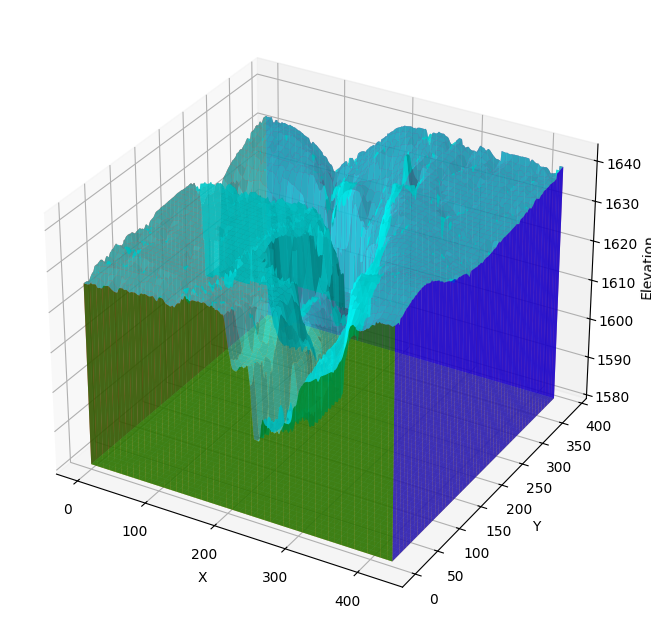

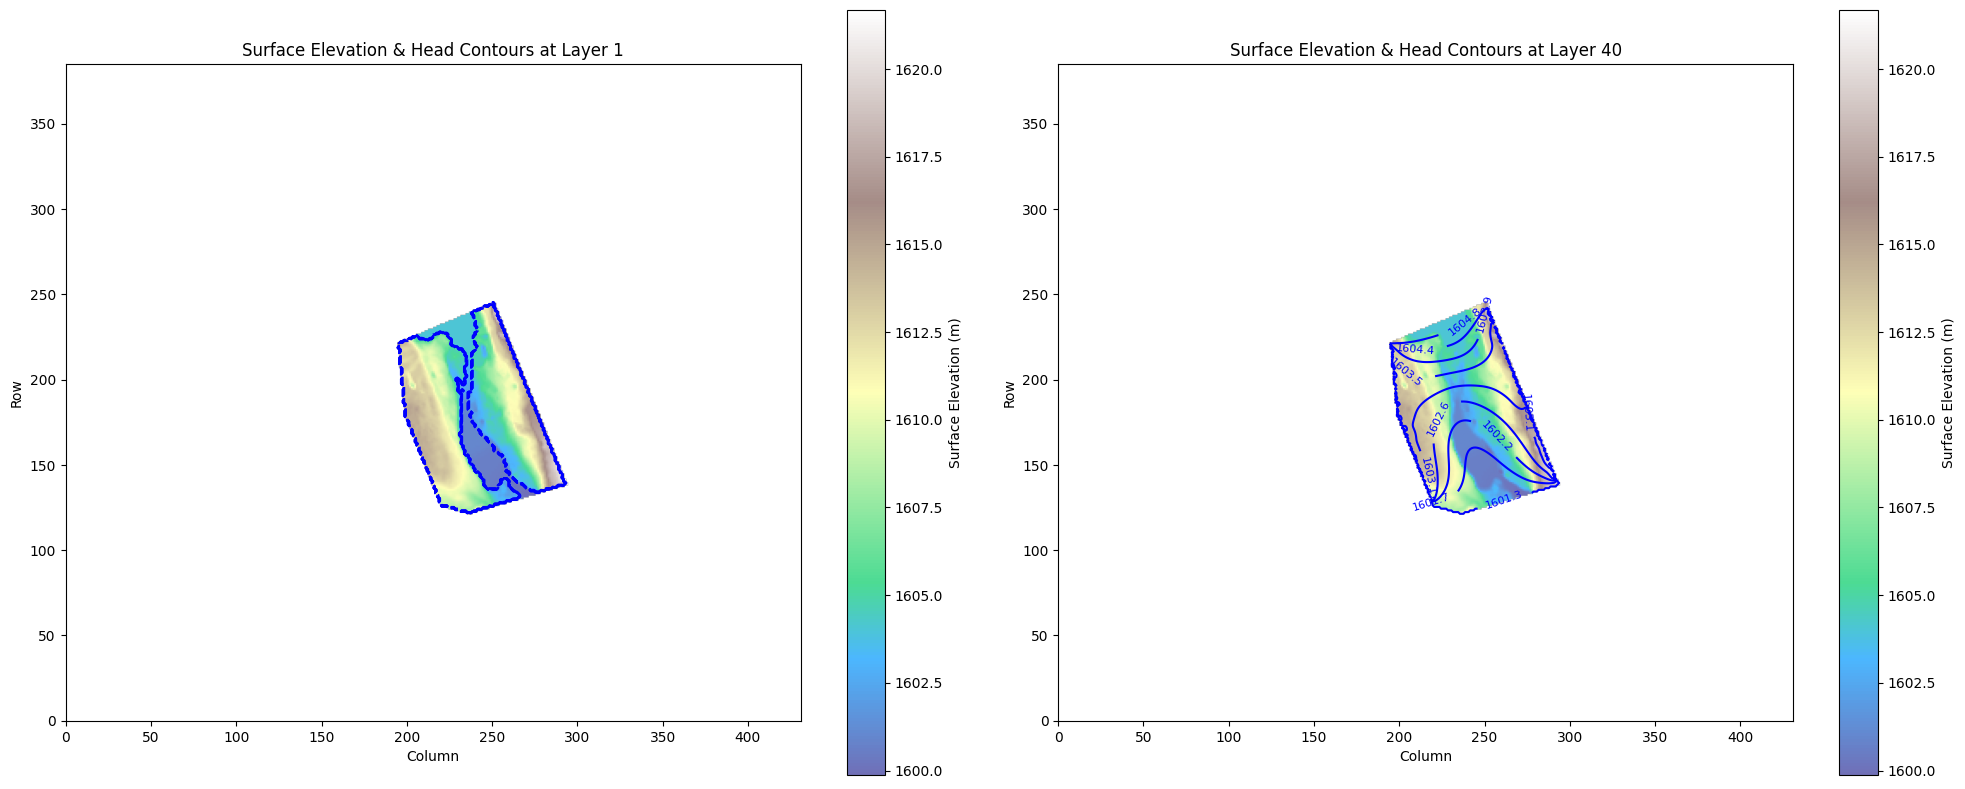

MODPATH 7 forward model built: MODPATH 7 model
MODPATH 7 backward model built: MODPATH 7 model
MODPATH 7 files written to: HP_workspace\mp7_workspace
Running MODPATH 7 forward model...
Running model: Hyporheic_Project_mp_forward


Simulation Hyporheic_Project_mp_forward succeeded.
run_models took 104740.45 ms
FINISHED! Running MODPATH 7 forward model
Running MODPATH 7 backward model...
Running model: Hyporheic_Project_mp_backward


Simulation Hyporheic_Project_mp_backward succeeded.
run_models took 101822.93 ms
FINISHED! Running MODPATH 7 backward model
Plotting MODPATH 7 Results



In [9]:
#---------------------- Simulation Scenario ------------------------#
def scenario(
    river_cells,
    cfg,
    chd_data,
    ncol,
    nrow,
    nlay,
    xorigin,
    yorigin,
    bed_elevation,
    hec_ras_crs,
    mp7_name,
    gwf_name,
    mp7_ws,
    gwf_ws,
    sim_name,
    mp7_exe_path,
    write=True,
    run=True,
    plot=True,
    silent=False,
):
    """
    Orchestrates the building, running, and plotting of the  MODFLOW 6 and MODPATH 7models.
    """
    # Build the GWF model using the new signature
    gwfsim, gwf = build_gwf_model(cfg, chd_data, idomain)

    print("GWF model built:", gwfsim)

    if write:
        write_models(gwfsim, silent=silent)
        print("GWF files written to:", cfg.gwf_ws)

    if run:
        print("Running MODFLOW model...")
        run_models(gwfsim, silent=False)
        print("FINISHED! Running GWF MODFLOW 6")

    if plot:
        print("Plotting Groundwater Flow Model")
        #plot_gwf_all(gwfsim)
        plot_groundwater_model(
        gwfsim,
        gwf_name=gwf_name,
        cfg=cfg
    )

    try:
        # Build both MODPATH 7 forward and backward models
        mp_forward, mp_backward = build_particle_models(
            cfg.sim_name, gwf, river_cells, mp7_ws=mp7_ws, exe_path=mp7_exe_path
        )

        print("MODPATH 7 forward model built:", mp_forward)
        print("MODPATH 7 backward model built:", mp_backward)

        if write:
            write_models(mp_forward, silent=silent)
            write_models(mp_backward, silent=silent)
            print("MODPATH 7 files written to:", mp7_ws)

        if run:
            print("Running MODPATH 7 forward model...")
            run_models(mp_forward, silent=silent)
            print("FINISHED! Running MODPATH 7 forward model")

            print("Running MODPATH 7 backward model...")
            run_models(mp_backward, silent=silent)
            print("FINISHED! Running MODPATH 7 backward model")

            if plot:
                print("Plotting MODPATH 7 Results")
                # process_and_export_modpath7_results(
                #     workspace=mp7_ws,
                #     workspace_gwf=gwf_ws,
                #     sim_name=sim_name,
                #     gwf_model_name=gwf_name,
                #     hec_ras_crs= hec_ras_crs,
                #     bed_elevation=bed_elevation,
                #     ncol=ncol,
                #     nrow=nrow,
                #     nlay=nlay,
                #     river_cells=river_cells,
                #     gwf=gwf,
                #     xorigin_value=xorigin,
                #     yorigin_value=yorigin,
                # )
    except Exception as e:
        print(f"An error occurred while building, running, or plotting the MODPATH 7 models: {e}")
    print('\a')  # This will make a beep in most terminals

# Example usage (assuming you have constructed cfg, chd_data, idomain, river_cells):
scenario(
    river_cells=river_cells,
    cfg=cfg,
    chd_data=chd_data,
    mp7_ws=mp7_ws,
    mp7_exe_path=md7_exe_path,
    write=True,
    run=True,
    plot=True,
    silent=True,
    ncol=ncol,
    nrow=nrow,
    nlay=nlay,
    xorigin=xorigin,
    yorigin=yorigin,
    bed_elevation=bed_elevation,
    hec_ras_crs=hec_ras_crs,
    mp7_name=mp7_name,
    gwf_name=gwf_name,
    gwf_ws=gwf_ws,
    sim_name=sim_name
)